In [50]:
import json
import numpy as np
import torch
import os


def load_diff_mean_data(path):
    data = {}
    with open(path, "r") as f:
        for line in f:
            item = json.loads(line)
            model = item["model"]
            benchmark = item["benchmark"]
            column = item["column"]
            id = f"{benchmark}/{column}/{model}"
            data[id] = np.array(item["diffmean"])
    return data

def load_linear_model_data(path):
    pt_files = [f for f in os.listdir(path) if f.endswith(".pt")]
    data = {}
    for pt_file in pt_files:
        temp = torch.load(os.path.join(path, pt_file))
        model = temp['model']
        benchmark = temp['benchmark']
        column = temp['column']
        id = f"{benchmark}/{column}/{model}"
        
        data[id] = temp['W']
        
    return data

In [51]:
embed_path = "../embeddings_pca_64/"


def map_back(vec_files, embed_path):
    output = []
    for key, vecs in vec_files.items():
        out = {}
        benchmark, column, model = key.split("/")
        embed_file = f"{benchmark}_{column}_{model}_pca_basis.pt"

        embed_file = torch.load(os.path.join(embed_path, "pca_basis", embed_file))
        
        vecs = np.array(vecs)  # (L,K)   
        pca_components = embed_file['pca_components'].numpy()
        # print( pca_components.shape)
        # print( vecs.shape)
        vecs_back = np.einsum('lk,lkd->ld', vecs, pca_components)
        



        out['benchmark'] = benchmark
        out['column'] = column
        out['model'] = model
        out['model_name'] = model
        out['vecs_back'] = vecs_back.tolist()
        output.append(out)
    return output




In [52]:
synthetic = True

if synthetic:
    hinge_path = "../linear_model/pca_64/synthetic_last_pca/hinge"
    logistic_path = "../linear_model/pca_64/synthetic_last_pca/logistic"
    diff_mean_path = "../diffmean_per_layer_synthetic_pca_64.jsonl"
    embed_path = "../embeddings_synthetic_pca_64/"
else:   
    hinge_path = "../linear_model/pca_64/last_pca/hinge"
    logistic_path = "../linear_model/pca_64/last_pca/logistic"
    diff_mean_path = "../diffmean_per_layer_pca_64.jsonl"
    embed_path = "../embeddings_pca_64/"




diff_mean = load_diff_mean_data(diff_mean_path)
hinge_data = load_linear_model_data(hinge_path)
logistic_data = load_linear_model_data(logistic_path)



diff_mean_back = map_back(diff_mean, embed_path)
hinge_back = map_back(hinge_data, embed_path)
logistic_back = map_back(logistic_data, embed_path)

if synthetic:
    diffmean_output_path = "pca_64/synthetic_diffmean_by_layer.jsonl"
    hinge_output_path = "pca_64/synthetic_hinge_by_layer.jsonl"
    logistic_output_path = "pca_64/synthetic_logistic_by_layer.jsonl"
else:
    diffmean_output_path = "pca_64/diffmean_by_layer.jsonl"
    hinge_output_path = "pca_64/hinge_by_layer.jsonl"
    logistic_output_path = "pca_64/logistic_by_layer.jsonl"


with open(diffmean_output_path, "w") as f:
    for item in diff_mean_back:
        f.write(json.dumps(item) + "\n")

with open(hinge_output_path, "w") as f:
    for item in hinge_back:
        f.write(json.dumps(item) + "\n")

with open(logistic_output_path, "w") as f:
    for item in logistic_back:
        f.write(json.dumps(item) + "\n")

# compare across dataset

In [56]:


import numpy as np
def cosine_between_benchmarks(data1, data2):
    results = []
    for item1 in data1:
        model = item1['model']
        benchmark1 = item1['benchmark']
        column1 = item1['column']
        vec1 = np.array(item1['vecs_back'])
        for item2 in data2:
            if item2['model'] != model:
                continue
            
            if item2['benchmark'] == benchmark1 and item2['column'] == column1:
                continue
            benchmark2 = item2['benchmark']
            column2 = item2['column']
            vec2 = np.array(item2['vecs_back'])
            
            out = {
                'benchmark1': benchmark1,
                'column1': column1,
                'benchmark2': benchmark2,
                'column2': column2,
                'model': model,
            }
            eps = 1e-8
            vec1_norm = vec1 / (np.linalg.norm(vec1, axis=1, keepdims=True) + eps)
            vec2_norm = vec2 / (np.linalg.norm(vec2, axis=1, keepdims=True) + eps)
            cos_sim = np.einsum('ld,ld->l', vec1_norm, vec2_norm)
            
            out['cosine_similarity'] = cos_sim.tolist()
            results.append(out)
    return results

In [57]:
import json

diffmean_synthetic_path = "pca_64/synthetic_diffmean_by_layer.jsonl"
hinge_synthetic_path = "pca_64/synthetic_hinge_by_layer.jsonl"
logistic_synthetic_path = "pca_64/synthetic_logistic_by_layer.jsonl"

diffmean_path = "pca_64/diffmean_by_layer.jsonl"
hinge_path = "pca_64/hinge_by_layer.jsonl"
logistic_path = "pca_64/logistic_by_layer.jsonl"

diffmean_synthetic = []
hinge_synthetic = []
logistic_synthetic = []

diffmean = []
hinge = []
logistic = []

with open(diffmean_synthetic_path, "r") as f:
    for line in f:
        diffmean_synthetic.append(json.loads(line))

with open(hinge_synthetic_path, "r") as f:
    for line in f:
        hinge_synthetic.append(json.loads(line))

with open(logistic_synthetic_path, "r") as f:
    for line in f:
        logistic_synthetic.append(json.loads(line))

with open(diffmean_path, "r") as f:
    for line in f:
        diffmean.append(json.loads(line))

with open(hinge_path, "r") as f:
    for line in f:
        hinge.append(json.loads(line))

with open(logistic_path, "r") as f:
    for line in f:
        logistic.append(json.loads(line))
    


In [59]:
diffmean_cosine = cosine_between_benchmarks(diffmean, diffmean_synthetic)
hinge_cosine = cosine_between_benchmarks(hinge, hinge_synthetic)
logistic_cosine = cosine_between_benchmarks(logistic, logistic_synthetic)

with open("pca_64/cosine_between_datasets_diffmean.jsonl", "w") as f:
    for item in diffmean_cosine:
        f.write(json.dumps(item) + "\n")

with open("pca_64/cosine_between_datasets_hinge.jsonl", "w") as f:
    for item in hinge_cosine:
        f.write(json.dumps(item) + "\n")

with open("pca_64/cosine_between_datasets_logistic.jsonl", "w") as f:
    for item in logistic_cosine:
        f.write(json.dumps(item) + "\n")



In [60]:
diffmean_cosine_real = cosine_between_benchmarks(diffmean, diffmean)
hinge_cosine_real = cosine_between_benchmarks(hinge, hinge)
logistic_cosine_real = cosine_between_benchmarks(logistic, logistic)

diffmean_cosine_synthetic = cosine_between_benchmarks(diffmean_synthetic, diffmean_synthetic)
hinge_cosine_synthetic = cosine_between_benchmarks(hinge_synthetic, hinge_synthetic)
logistic_cosine_synthetic = cosine_between_benchmarks(logistic_synthetic, logistic_synthetic)

with open("pca_64/cosine_within_dataset_diffmean_real.jsonl", "w") as f:
    for item in diffmean_cosine_real:
        f.write(json.dumps(item) + "\n")

with open("pca_64/cosine_within_dataset_hinge_real.jsonl", "w") as f:
    for item in hinge_cosine_real:
        f.write(json.dumps(item) + "\n")

with open("pca_64/cosine_within_dataset_logistic_real.jsonl", "w") as f:
    for item in logistic_cosine_real:
        f.write(json.dumps(item) + "\n")



with open("pca_64/cosine_within_dataset_diffmean_synthetic.jsonl", "w") as f:
    for item in diffmean_cosine_synthetic:
        f.write(json.dumps(item) + "\n")
with open("pca_64/cosine_within_dataset_hinge_synthetic.jsonl", "w") as f:
    for item in hinge_cosine_synthetic:
        f.write(json.dumps(item) + "\n")
with open("pca_64/cosine_within_dataset_logistic_synthetic.jsonl", "w") as f:
    for item in logistic_cosine_synthetic:
        f.write(json.dumps(item) + "\n")

## plot

In [71]:
import json
import numpy as np

diffmean_cosine_path = "pca_64/cosine_within_dataset_diffmean_synthetic.jsonl"
hinge_cosine_path = "pca_64/cosine_within_dataset_hinge_synthetic.jsonl"
logistic_cosine_path = "pca_64/cosine_within_dataset_logistic_synthetic.jsonl"

with open(diffmean_cosine_path, "r") as f:
    diffmean_cosine = [json.loads(line) for line in f]
with open(hinge_cosine_path, "r") as f:
    hinge_cosine = [json.loads(line) for line in f]
with open(logistic_cosine_path, "r") as f:
    logistic_cosine = [json.loads(line) for line in f]


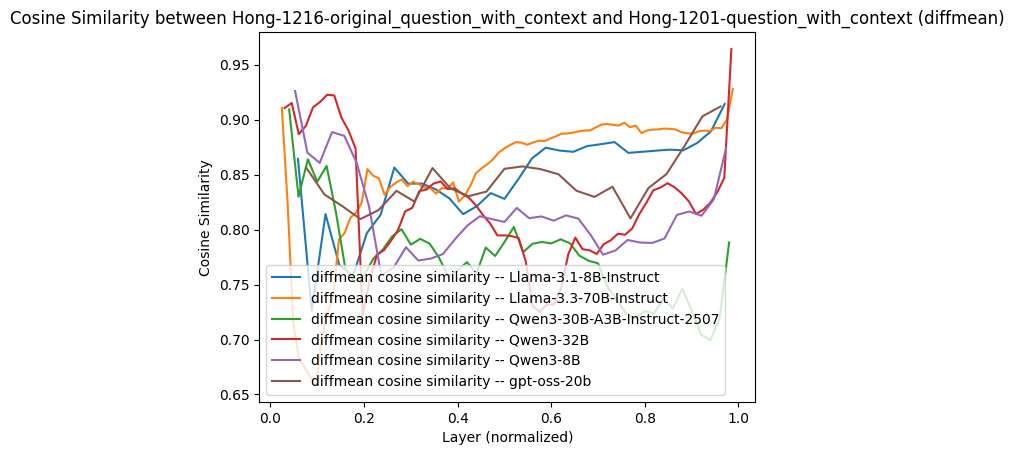

In [72]:
import matplotlib.pyplot as plt
import pandas as pd

benchmark1 = "Hong-1216"
column1 = "original_question_with_context"
benchmark2 = "Hong-1201"
column2 = "question_with_context"
metric = "diffmean"


if metric == "diffmean":
    data = diffmean_cosine
elif metric == "hinge":
    data = hinge_cosine
elif metric == "logistic":
    data = logistic_cosine
    
for item in data:
    
    if (item['benchmark1'] == benchmark1 and item['column1'] == column1 and
        item['benchmark2'] == benchmark2 and item['column2'] == column2):
        layers = np.arange(1, len(item['cosine_similarity']) + 1)
        plt.plot(layers[1:]/(len(layers)+1), item['cosine_similarity'][1:], label=f"{metric} cosine similarity -- {item['model']}")
        plt.legend()
    
plt.xlabel("Layer (normalized)")
plt.ylabel("Cosine Similarity")
plt.title(f"Cosine Similarity between {benchmark1}-{column1} and {benchmark2}-{column2} ({metric})")
plt.show()

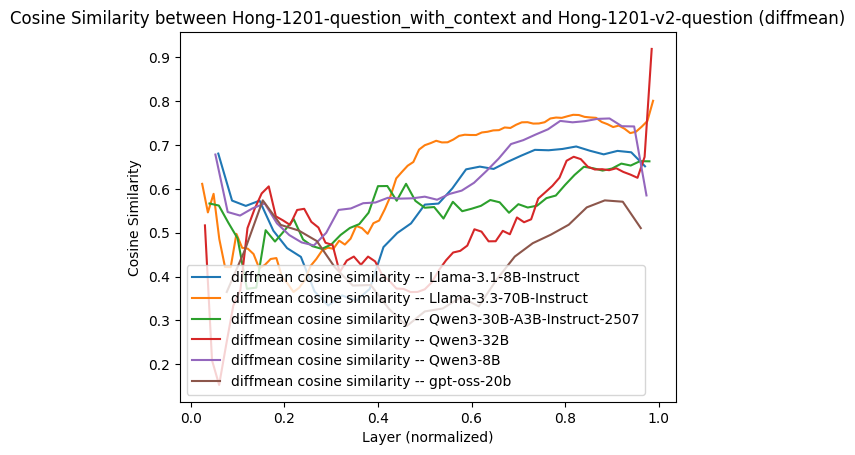

In [74]:
import matplotlib.pyplot as plt
import pandas as pd

benchmark1 = "Hong-1201"
column1 = "question_with_context"
benchmark2 = "Hong-1201-v2"
column2 = "question"
metric = "diffmean"


if metric == "diffmean":
    data = diffmean_cosine
elif metric == "hinge":
    data = hinge_cosine
elif metric == "logistic":
    data = logistic_cosine
    
for item in data:
    
    if (item['benchmark1'] == benchmark1 and item['column1'] == column1 and
        item['benchmark2'] == benchmark2 and item['column2'] == column2):
        layers = np.arange(1, len(item['cosine_similarity']) + 1)
        plt.plot(layers[1:]/(len(layers)+1), item['cosine_similarity'][1:], label=f"{metric} cosine similarity -- {item['model']}")
        plt.legend()
    
plt.xlabel("Layer (normalized)")
plt.ylabel("Cosine Similarity")
plt.title(f"Cosine Similarity between {benchmark1}-{column1} and {benchmark2}-{column2} ({metric})")
plt.show()

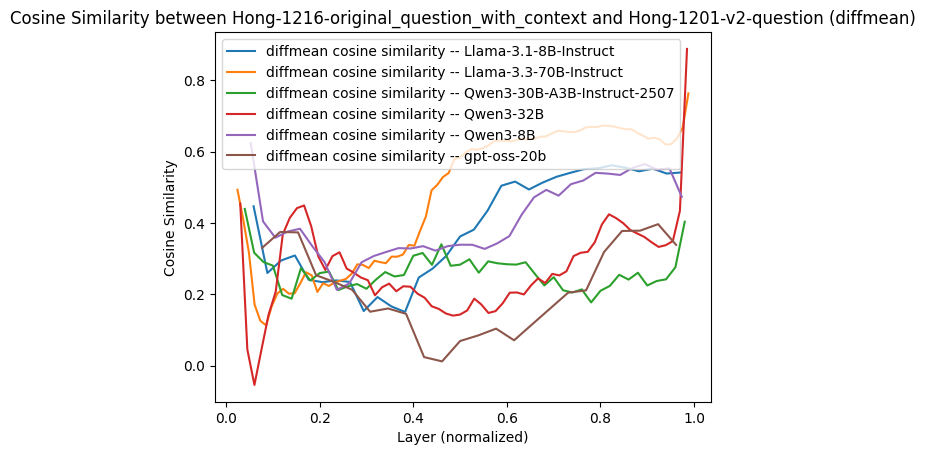

In [75]:
import matplotlib.pyplot as plt
import pandas as pd

benchmark1 = "Hong-1216"
column1 = "original_question_with_context"
benchmark2 = "Hong-1201-v2"
column2 = "question"
metric = "diffmean"


if metric == "diffmean":
    data = diffmean_cosine
elif metric == "hinge":
    data = hinge_cosine
elif metric == "logistic":
    data = logistic_cosine
    
for item in data:
    
    if (item['benchmark1'] == benchmark1 and item['column1'] == column1 and
        item['benchmark2'] == benchmark2 and item['column2'] == column2):
        layers = np.arange(1, len(item['cosine_similarity']) + 1)
        plt.plot(layers[1:]/(len(layers)+1), item['cosine_similarity'][1:], label=f"{metric} cosine similarity -- {item['model']}")
        plt.legend()
    
plt.xlabel("Layer (normalized)")
plt.ylabel("Cosine Similarity")
plt.title(f"Cosine Similarity between {benchmark1}-{column1} and {benchmark2}-{column2} ({metric})")
plt.show()

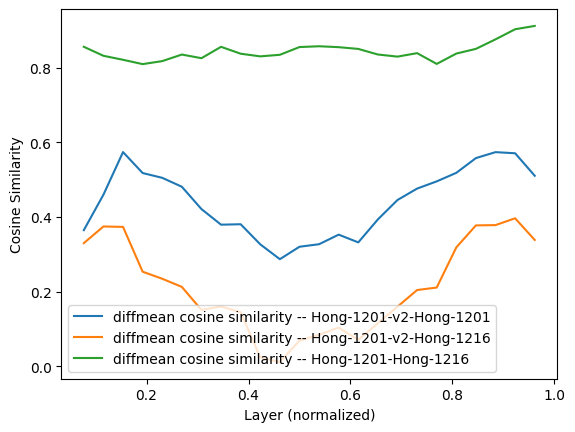

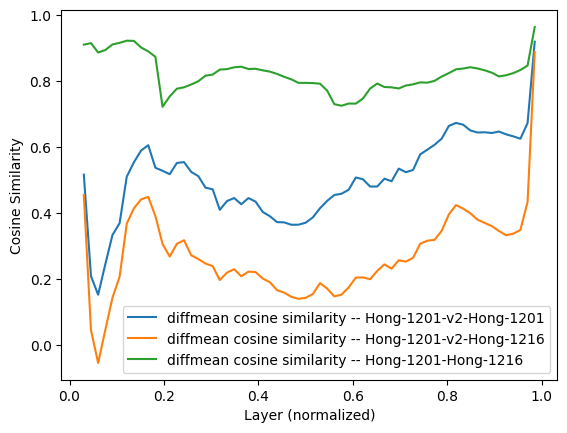

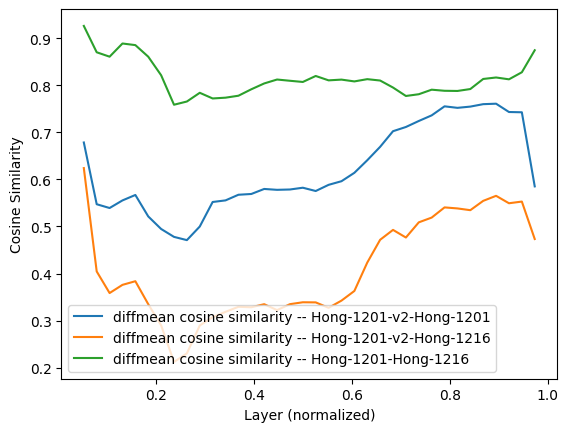

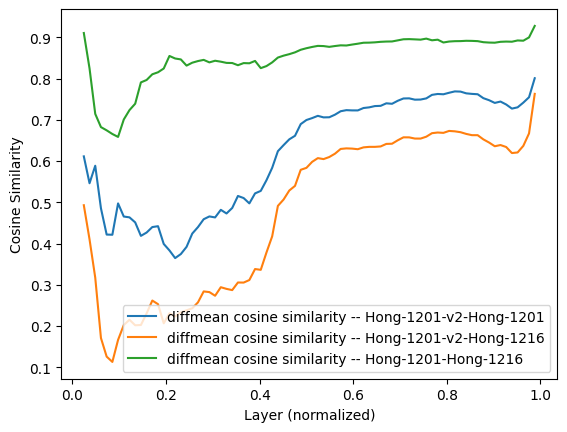

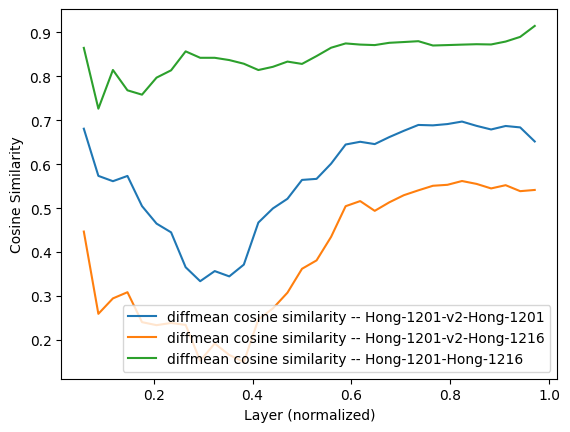

In [102]:
import matplotlib.pyplot as plt
import pandas as pd

synthetic_benchmarks = [
    ("Hong-1216", "original_question_with_context"),
    ("Hong-1201", "question_with_context"),
    ("Hong-1201-v2", "question"),
]



metric = "diffmean"
if metric == "diffmean":
    data = diffmean_cosine
elif metric == "hinge":
    data = hinge_cosine
elif metric == "logistic":
    data = logistic_cosine
    
models = ['gpt-oss-20b', 'Qwen3-32B', 'Qwen3-8B', 'Llama-3.3-70B-Instruct', 'Llama-3.1-8B-Instruct']

for model in models:
    plotted = set()
    for item in data:
        if item['model'] == model:

        # print(item['benchmark1'], item['column1'], item['benchmark2'], item['column2'], item['model'])

            if (item['benchmark1'], item['column1'], item['benchmark2'], item['column2']) in plotted:
                continue
            elif (item['benchmark2'], item['column2'], item['benchmark1'], item['column1']) in plotted:
                # print("skipping")
                continue
            else:
                plotted.add((item['benchmark1'], item['column1'], item['benchmark2'], item['column2']))
                plotted.add((item['benchmark2'], item['column2'], item['benchmark1'], item['column1']))
                # print(plotted)
                layers = np.arange(1, len(item['cosine_similarity']) + 1)
                plt.plot(layers[1:]/(len(layers)+1), item['cosine_similarity'][1:], label=f"{metric} cosine similarity -- {item['benchmark1']}-{item['benchmark2']}")
                plt.legend()
    
    plt.xlabel("Layer (normalized)")
    plt.ylabel("Cosine Similarity")
    # plt.title(f"Cosine Similarity between {benchmark1}-{column1} and {benchmark2}-{column2} ({metric})")
    plt.show()

In [106]:
import pandas as pd


hong_1216 = pd.read_csv("../Hong-1216.csv")


hong_1216[['question_with_context', 'original_question_with_context', 'binary_label']]

,question_with_context,original_question_with_context,binary_label
0,Some findings from the experiment indicate tha...,Some findings from the experiment indicate tha...,0
1,"After all the meetings, reports, and promises,...","After all the meetings, reports, and promises,...",1
2,"In our notes, we wrote that vaccines always pr...","In our notes, we wrote that vaccines always pr...",0
3,"Considering the situation, nothing makes sense...","Considering the situation, nothing makes sense...",1
4,"In practice, we often encounter situations whe...","In practice, we often encounter situations whe...",0
...,...,...,...
9894,Some observations from the experiment indicate...,Some observations from the experiment indicate...,0
9895,Everyone keeps pretending things are under con...,Everyone keeps pretending things are under con...,1
9896,Some observations from the experiment indicate...,Some observations from the experiment indicate...,0
9897,"We conducted several tests, and the results sh...","We conducted several tests, and the results sh...",0


In [109]:
hong_1216.columns

Index(['original_context', 'original_question', 'label', 'subfield', 'id',
       'binary_label', 'context', 'question', 'question_with_context',
       'dataset', 'original_question_with_context'],
      dtype='object')